In [7]:
import json
from freezeplots import (
    combined,
    complete,
    plot_supercooling,
)


from freezeplots.paths import PROC_DATA_DIR, PLOT_DIR, CHANNEL_LAYOUT_PATH
with CHANNEL_LAYOUT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    channel_layout = json.load(file)

input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "EJ06-8.png"

In [14]:
# ============================================================
# Temperature treatments
# ============================================================

TEMPERATURE_EXPERIMENTS = {
    "RT": [
        "EJ06A1",
        "EJ06A2",
    ],
    "40°C": [
        "EJ07A1",
        "EJ07A2",
    ],
    "100°C": [
        "EJ08A1",
        "EJ08A2",
    ],
}


# ============================================================
# Treatment colors
# ============================================================

TREATMENT_COLORS = {
    "RT": "#4C78A8",      # blue
    "40°C": "#F2A541",    # orange
    "100°C": "#C44E52",   # red
}

In [15]:
def temperature_comparison(channel):
    """
    Create RT, 40°C, and 100°C boxplots for one TC channel.

    Each boxplot pools the corresponding channel from the two
    repeated experiments.
    """
    return [
        combined(
            temperature_label,
            {
                experiment_id: [channel]
                for experiment_id in experiment_ids
            },
        )
        for temperature_label, experiment_ids
        in TEMPERATURE_EXPERIMENTS.items()
    ]

In [20]:
# ============================================================
# Temperature treatments
# ============================================================

TEMPERATURE_EXPERIMENTS = {
    "RT": ["EJ06A1", "EJ06A2"],
    "40°C": ["EJ07A1", "EJ07A2"],
    "100°C": ["EJ08A1", "EJ08A2"],
}


TREATMENT_COLORS = {
    "RT": "#4C78A8",
    "40°C": "#F2A541",
    "100°C": "#C44E52",
}


def temperature_comparison(channel):
    """Pool repetitions for RT, 40°C, and 100°C."""

    return [
        combined(
            temperature_label,
            {
                experiment_id: [channel]
                for experiment_id in experiment_ids
            },
        )
        for temperature_label, experiment_ids
        in TEMPERATURE_EXPERIMENTS.items()
    ]


# ============================================================
# Only 100 µl channels
# ============================================================
#
# Included:
# Weta:        TC1–TC4
# Grasshopper: TC9–TC12
#
# Excluded:
# TC5–TC8 and TC13–TC16

plot_sections = [
    {
        "label": "Weta\nEJ05 probe · 1:100",
        "gap_after": 0.8,
        "plots": temperature_comparison("TC1"),
    },
    {
        "label": "Weta\nEJ05 probe · 1:200",
        "gap_after": 0.8,
        "plots": temperature_comparison("TC2"),
    },
    {
        "label": "Weta\nStock probe · 1:100",
        "gap_after": 0.8,
        "plots": temperature_comparison("TC3"),
    },
    {
        "label": "Weta\nStock probe · 1:200",
        "gap_after": 2.0,
        "plots": temperature_comparison("TC4"),
    },

    {
        "label": "Grasshopper\nEJ05 probe · 1:100",
        "gap_after": 0.8,
        "plots": temperature_comparison("TC9"),
    },
    {
        "label": "Grasshopper\nEJ05 probe · 1:200",
        "gap_after": 0.8,
        "plots": temperature_comparison("TC10"),
    },
    {
        "label": "Grasshopper\nStock probe · 1:100",
        "gap_after": 0.8,
        "plots": temperature_comparison("TC11"),
    },
    {
        "label": "Grasshopper\nStock probe · 1:200",
        "gap_after": 0.8,
        "plots": temperature_comparison("TC12"),
    },
]

Loaded 871 channel records from /home/juk/freeze/data/data_processed/manual_supercooling_events.csv
Plot saved to: /home/juk/freeze/output/plots/EJ06-8.png


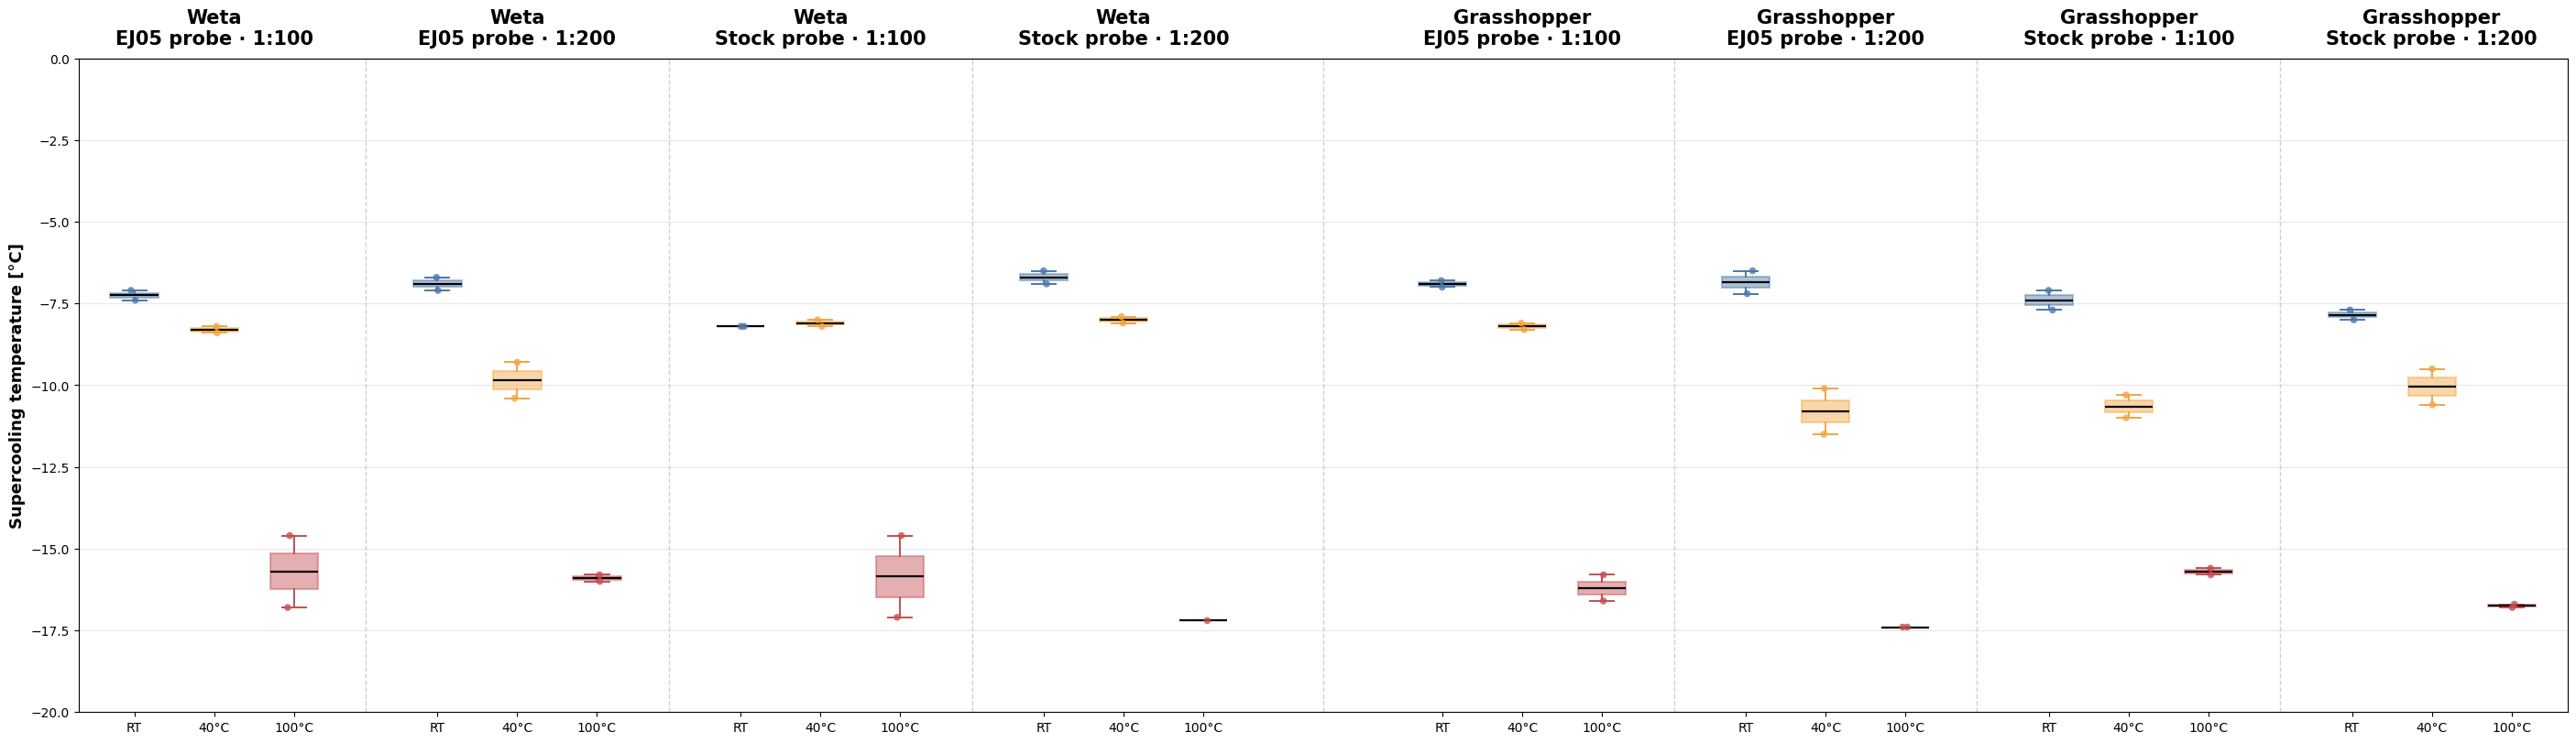

(<Figure size 2800x800 with 1 Axes>,
 <Axes: ylabel='Supercooling temperature [°C]'>)

In [29]:
plot_supercooling(
    plot_sections=plot_sections,
    treatment_colors=TREATMENT_COLORS,
    input_path=input_path,
    output_path=output_path,
    title=None,
    y_range=(-20, 0),
    figsize=(28, 8),
    x_label_rotation=0,
    tick_label_size=10,
    group_label_size=15,
    axis_label_size=13,

    point_size=30,
    jitter_scale=0.04,

    show_legend=False,
    legend_title="Heat treatment",
)